# Imports
---

In [57]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [58]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/hojjatk/mnist-dataset/train-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte


# #1 Data Handling
---

In [59]:
!pip install idx2numpy
import idx2numpy
base_path = '/kaggle/input/datasets/hojjatk/mnist-dataset'

# Load the files directly
train_images = idx2numpy.convert_from_file(f'{base_path}/train-images.idx3-ubyte')
train_labels = idx2numpy.convert_from_file(f'{base_path}/train-labels.idx1-ubyte')
test_images = idx2numpy.convert_from_file(f'{base_path}/t10k-images.idx3-ubyte')
test_labels = idx2numpy.convert_from_file(f'{base_path}/t10k-labels.idx1-ubyte')

# Flatten images from 28x28 to 784
train_images = train_images.reshape(train_images.shape[0], -1)
test_images = test_images.reshape(test_images.shape[0], -1)

# Combine into one DataFrame
all_images = np.concatenate([train_images, test_images], axis=0)
all_labels = np.concatenate([train_labels, test_labels], axis=0)

df = pd.DataFrame(all_images, columns=[f'pixel{i}' for i in range(784)])
df.insert(0, 'label', all_labels)

In [60]:
df.shape

(70000, 785)

In [61]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [62]:
df[['label']].value_counts()

label
1        7877
7        7293
3        7141
2        6990
9        6958
0        6903
6        6876
8        6825
4        6824
5        6313
Name: count, dtype: int64

In [63]:
X = df.drop('label', axis=1).values
y = df['label'].values  

In [64]:
# 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=12, stratify=y
)

# split the 40% into 20% validation and 20% test (50/50 of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=12, stratify=y_temp
)

In [65]:
print(f"train: {X_train.shape}")
print(f"val:   {X_val.shape}")
print(f"test:  {X_test.shape}")

train: (42000, 784)
val:   (14000, 784)
test:  (14000, 784)


In [66]:
# convert numpy arrays to PyTorch tensors
# normalize pixel values from 0-255 to 0-1
X_train_tensor = torch.FloatTensor(X_train) / 255.0
y_train_tensor = torch.LongTensor(y_train)

X_val_tensor = torch.FloatTensor(X_val) / 255.0
y_val_tensor = torch.LongTensor(y_val)

X_test_tensor = torch.FloatTensor(X_test) / 255.0
y_test_tensor = torch.LongTensor(y_test)

In [67]:
# create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [68]:
# create DataLoaders
batch_size = 80
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

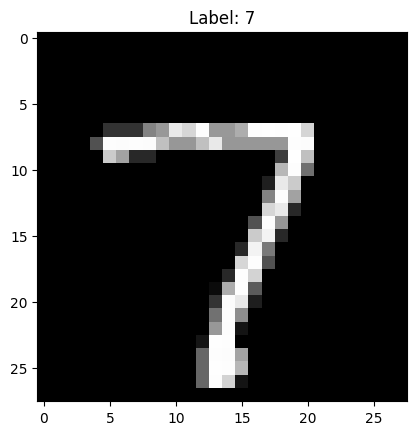

In [69]:
# test
image, label = train_dataset[512]
image_2d = image.reshape(28, 28)
plt.imshow(image_2d, cmap='gray')
plt.title(f"Label: {label.item()}")
plt.show()